# [IAPR][iapr]: Lab 2 ‒  Object description


**Group ID:** 34

**Author 1 (sciper):** Aaron Kuriakose Dinesh (387804) \
**Author 2 (sciper):** Niyazi Görkem Dener (370763)   
**Author 3 (sciper):** Lunnet Newman Yokomizo (387120)   


**Release date:** 26.03.2025  
**Due date:** 09.04.2025 (11:59 pm)


## Key Submission Guidelines:

- **Before submitting your notebook, <span style="color:red;">rerun</span> it from scratch!** Go to: `Kernel` > `Restart & Run All`  
- **Only groups of three will be accepted**, except in exceptional circumstances.  
- **You are not allowed to use any libraries** other than those provided in this notebook.  
- **TAs must be able to run your code from start to finish without any issues.**  
- **Failure to follow these guidelines may result in point deductions** during grading.  


[iapr]: https://github.com/LTS5/iapr2025

In [39]:
######################################################
############ Check it is python 3.9 ##################
## DO NOT COMMENT, WE WILL TEST YOUR CODE WITH 3.9 ###
######################################################

import sys 
assert (sys.version_info.major == 3) and (sys.version_info.minor == 9)

In [40]:
# Install required packages
# !pip install wget -q
# !pip install numpy -q
# !pip install matplotlib -q
# !pip install scikit-image -q
# !pip install scikit-learn -q
# !pip install python-mnist -q
# !pip install opencv-python -q

In [41]:
# Import main packages
from utils.lab_02_utils import *
from skimage.morphology import remove_small_objects, remove_small_holes, closing, disk, opening
from skimage.transform import rotate, resize
from sklearn.metrics.pairwise import euclidean_distances
from skimage.measure import regionprops, find_contours

import cv2
import numpy as np

---
# Introduction

In this lab, we will work with the famous MNIST dataset. It is composed of thousands of images (size 28x28) that depict handwritten digits from 0 to 9. The code below will automatically download the data from the online repo. This lab aims to create discriminant features from handwritten digits using various approaches. 


Take a look at the data to get a better idea of what you will be working within this lab.

Data downloaded under folder: ../data/data_lab_02
60000 Images and 60000 labels loaded


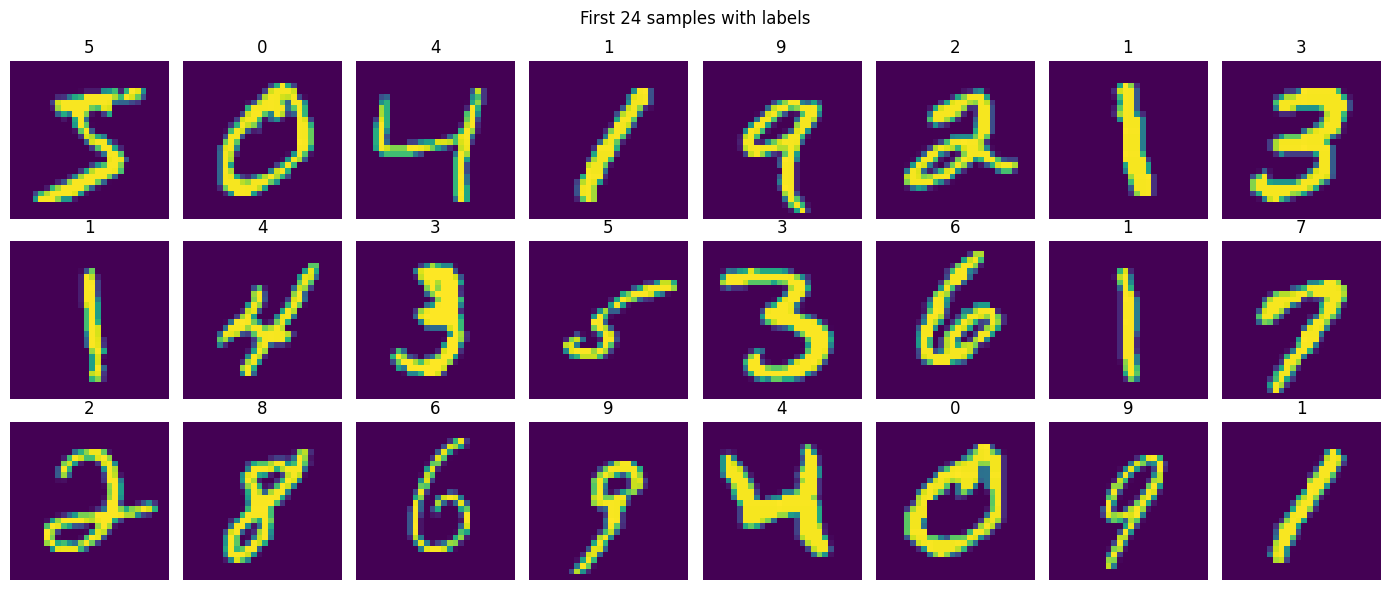

In [42]:
images, labels = load_lab02_data()

---
# Part 1 - Preprocessing [2 pts]


In this lab, we will create different feautre descriptors from digits. However, we will not use all images in the dataset. We will focus on the digits "0" and "4".

## 1.1 Selection (1 pt)

**Q1 (1 pt)** Your first task is to complete the function `extract_label` such that it selects from the input data only the images that are labeled as a given `target_label`. This function will be used to extract 0s and 4s from the data cohort. When running the code, the plots should only show you samples that are 0s (first plot) and 4s (second plot)

In [43]:
def extract_label(images: np.ndarray, labels: np.ndarray, target_label: int):
    """
    The function returns only the images that have target_label as labels.
    
    Args
    ----
    images: np.ndarray (N, 28, 28)
        Source images - handwritten digits 
    labels: np.ndarray (N)
        List of labels associated with the input image
    target_label: int
        Selected target label

    Return
    ------
    img_extract: np.ndarray (M, 28, 28)
        Extracted images that have target_label as label (M should be lower than N).
    """

    n, d, _ = np.shape(images) 
    img_extract = np.zeros((30, d, d))

    #Find out which images have the target label
    desired_labels = np.where(labels == target_label)[0]
    #Extrack all those images using boolean indexing
    img_extract = images[desired_labels, :, :]

    return img_extract

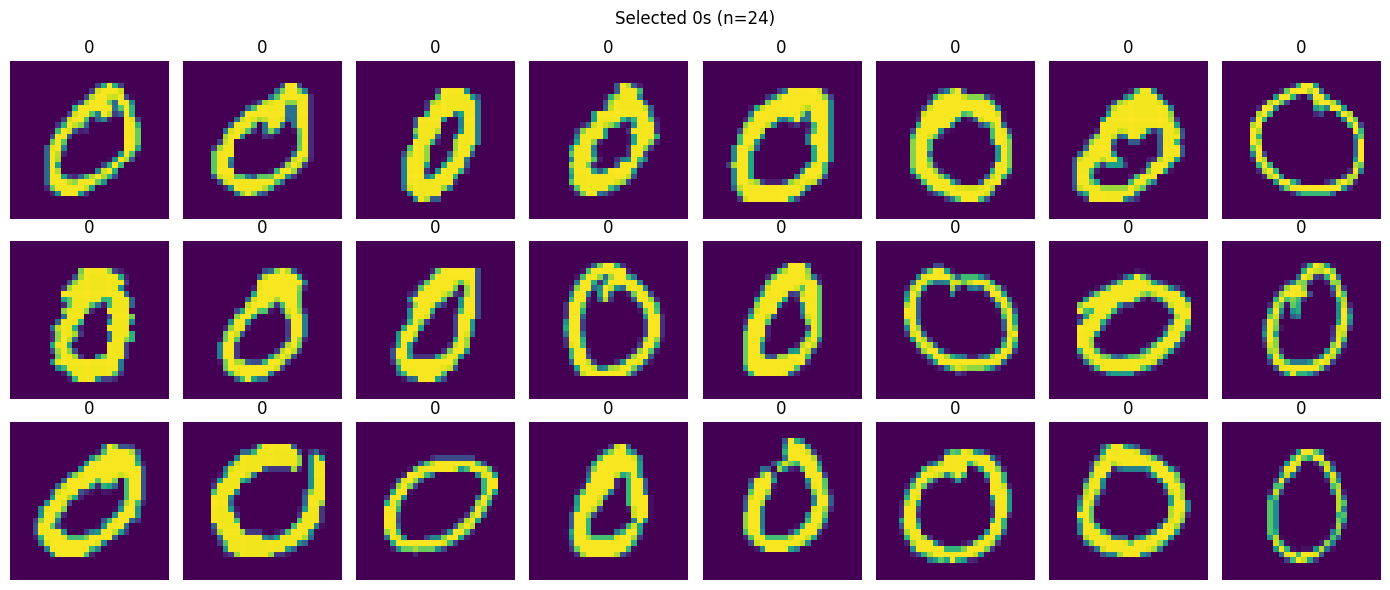

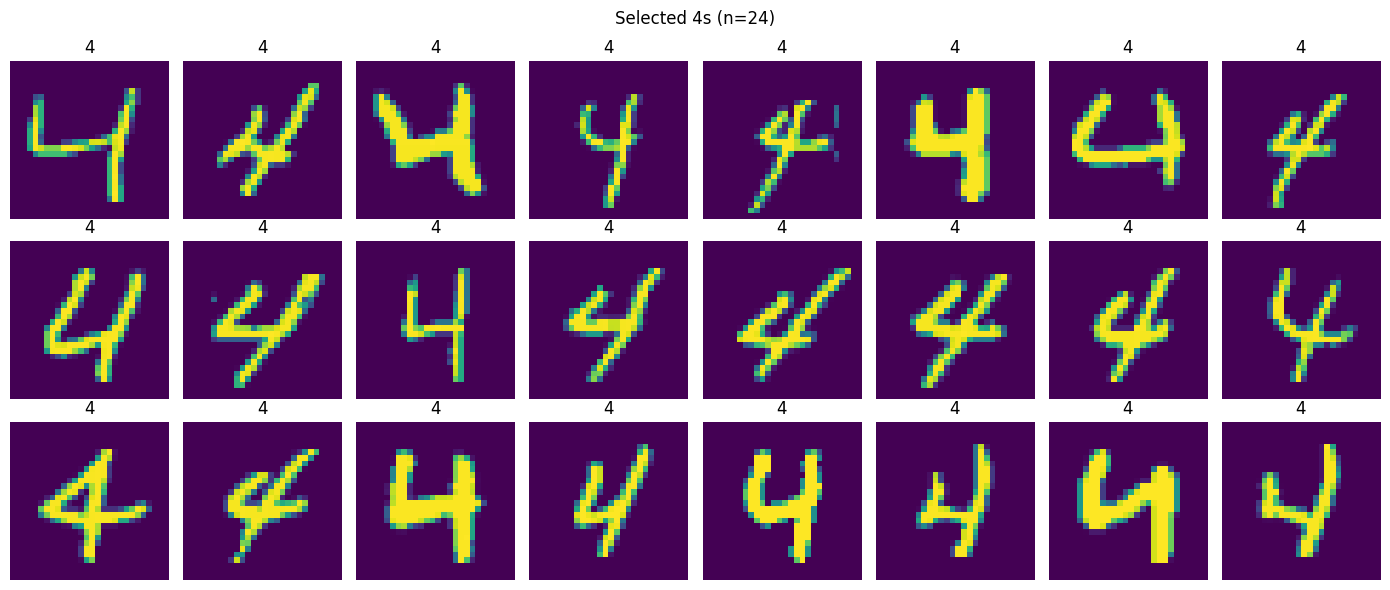

In [44]:
################################################################
############################ TEST ##############################
################################################################

images_a, images_b = test_1_1(extract_label, images, labels)

## 1.2 Preprocessing (1 pt)

Before computing the Fourier descriptors we need to preprocess the images.

* **Q1 (1 pt)**: Complete the function `preprocess` such that it cleans the input images. Take a look at the example images above and try to think what could be improved to allow better uniformity of the data. Take advantage of what you have learned in the previous lab.

Comment: we did thresholding. We tried morphological transformations but they didn't yield better performance. Closing made the 0s better, but made the 4s worse for instance. Opening operations degraded the images too much. In our implementation, we consider internal contours as well as the external ones, and so closing up holes in the 4s makes them less distinguishable from 0s.

In [45]:
def preprocess(images: np.ndarray):
    """
    Apply the processing step to images to achieve better data uniformity.
    
    Args
    ----
    images: np.ndarray (N, 28, 28)
        Source images

    Return
    ------
    img_process: np.ndarray (N, 28, 28)
        Processed images.
    """

    # Get the shape of input data and set dummy values
    n, d, _ = np.shape(images) 
    images = images > 0.5*255
    #images = [closing(x, disk(1)) for x in images]
    #images = [opening(x, disk(1)) for x in images]
    #images = [remove_small_objects(x, 5) for x in images]
    #images = [remove_small_holes(x, 2) for x in images]
    #images = np.array(images).astype(np.uint8)
    images = images.astype(np.uint8)

    return images

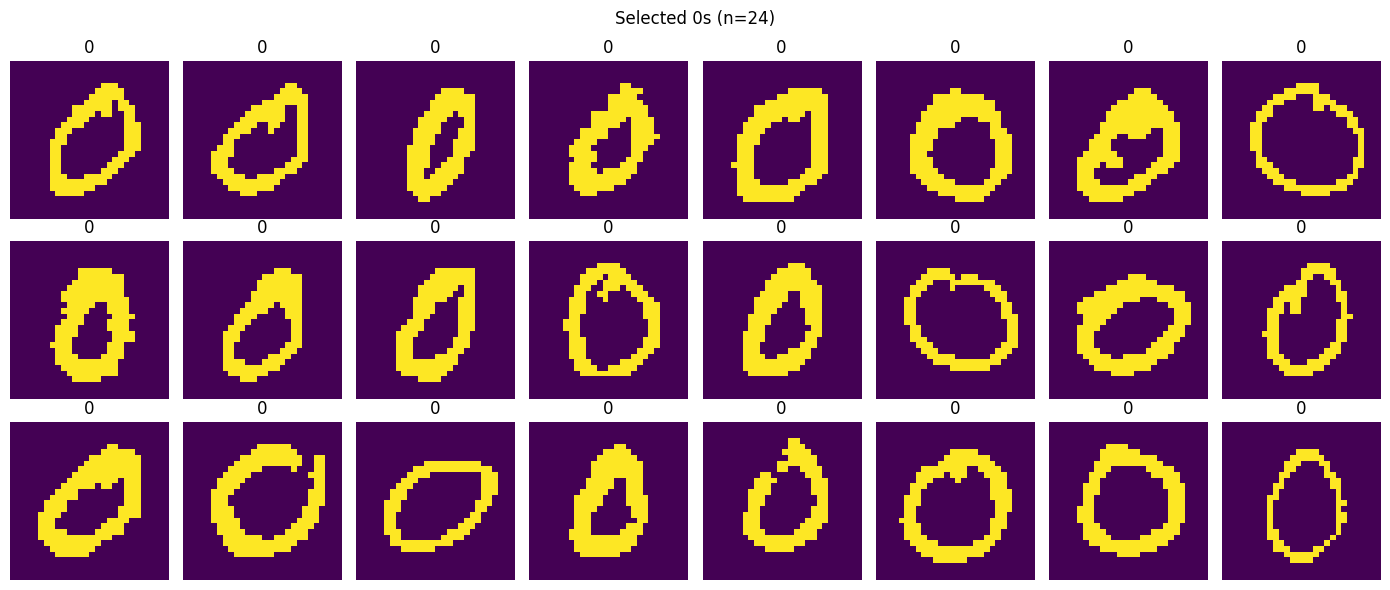

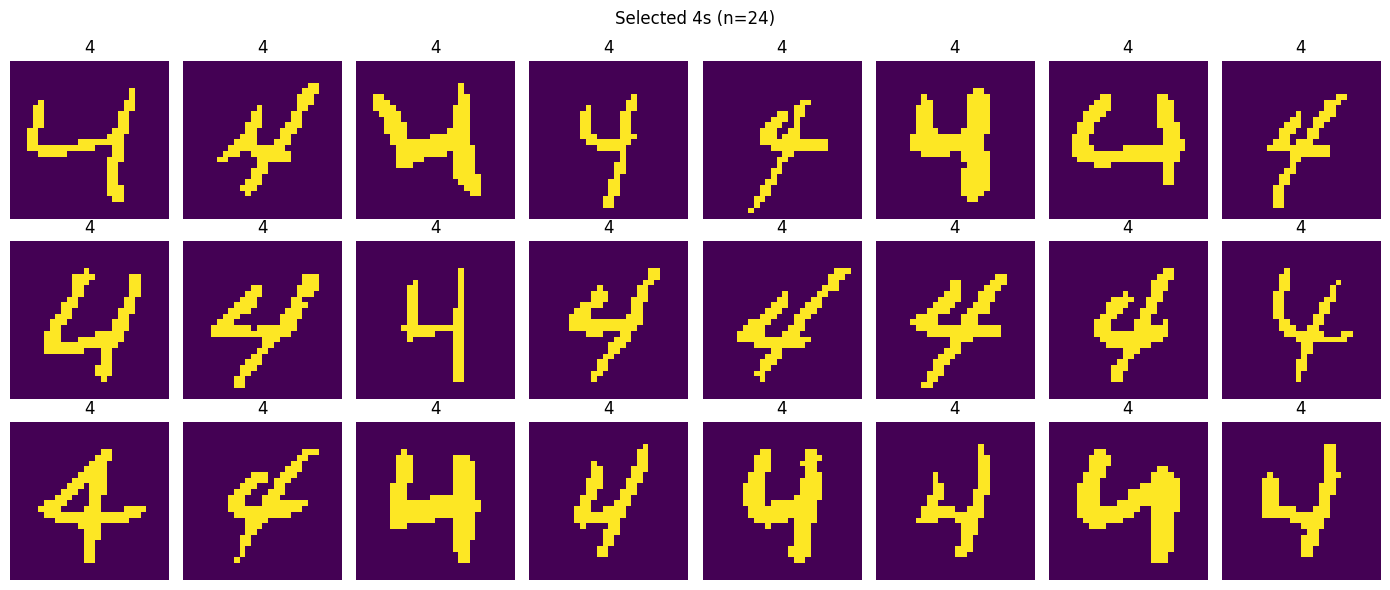

In [46]:
################################################################
############################ TEST ##############################
################################################################

images_p_a, images_p_b = test_1_2(preprocess, images_a, images_b)

---
# Part 2 - Fourier Descriptors [17 pts]


## 2.1. Get contour and descriptors (9 pts)

In this section, we will create Fourier descriptors from digits. The next step in our pipeline will be to detect the contours. To do so you can use existing algorithm available online such as `find_contours`([doc](https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.find_contours)) from skcit-image or `findContours` ([doc](https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html#gadf1ad6a0b82947fa1fe3c3d497f260e0)) from opencv. Pay attention to the coordinate system when using the contour detection function (is the first component x or y coordinate?).

* **Q1 (2 pts)**: Complete the function `find_contour` below such that it returns the contour estimations of the given images. The provided `display_samples` function will display the returned contours for a subset of images.

In [47]:
from cv2 import findContours


def find_contour(images: np.ndarray):
    """
    Find the contours for the set of images
    
    Args
    ----
    images: np.ndarray (N, 28, 28)
        Source images to process

    Return
    ------
    contours: list of np.ndarray
        List of N arrays containing the coordinates of the contour. Each element of the 
        list is an array of 2d coordinates (K, 2) where K depends on the number of elements 
        that form the contour. 
    """

    # Get number of images to process
    N, _, _ = np.shape(images)
    # Fill in dummy values (fake points)
    result = []

    
    for img in images:
        contours, _ = cv2.findContours(img, cv2.RETR_LIST , cv2.CHAIN_APPROX_NONE)

        # Merge all contours into a single (K, 2) array
        if contours:
            merged = np.vstack([cnt.squeeze() for cnt in contours if cnt.shape[1] == 1])
        else:
            merged = np.empty((0, 2), dtype=np.int32)

        result.append(merged)


    return result

1000


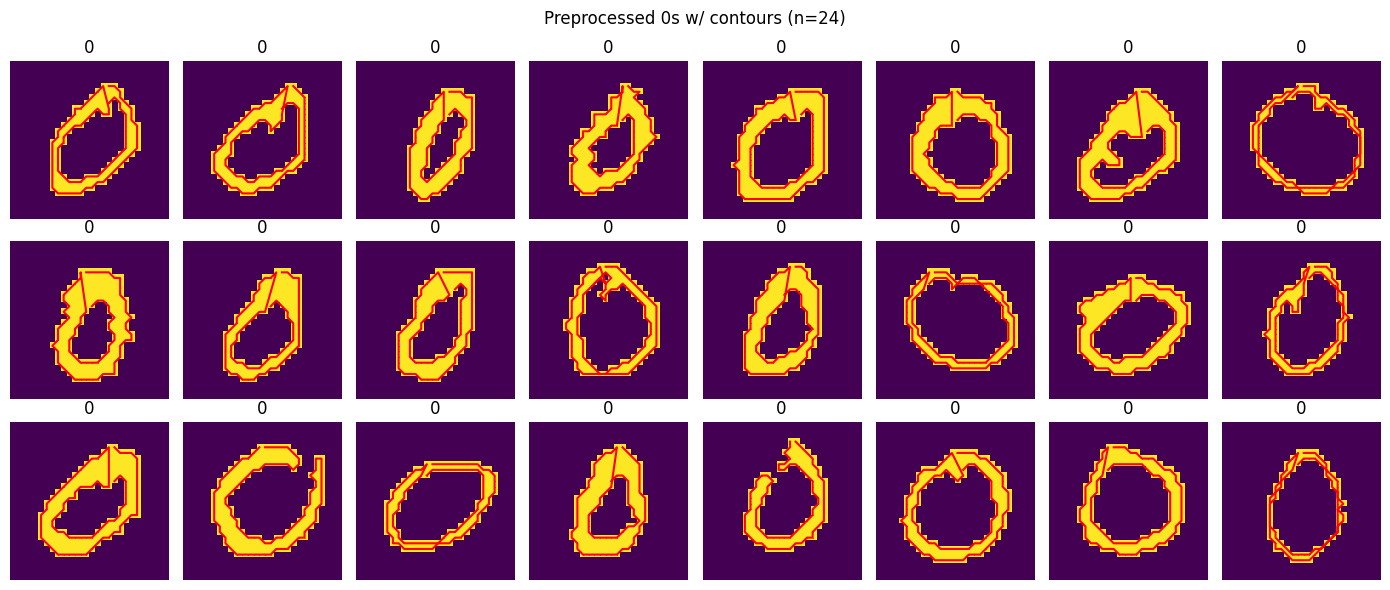

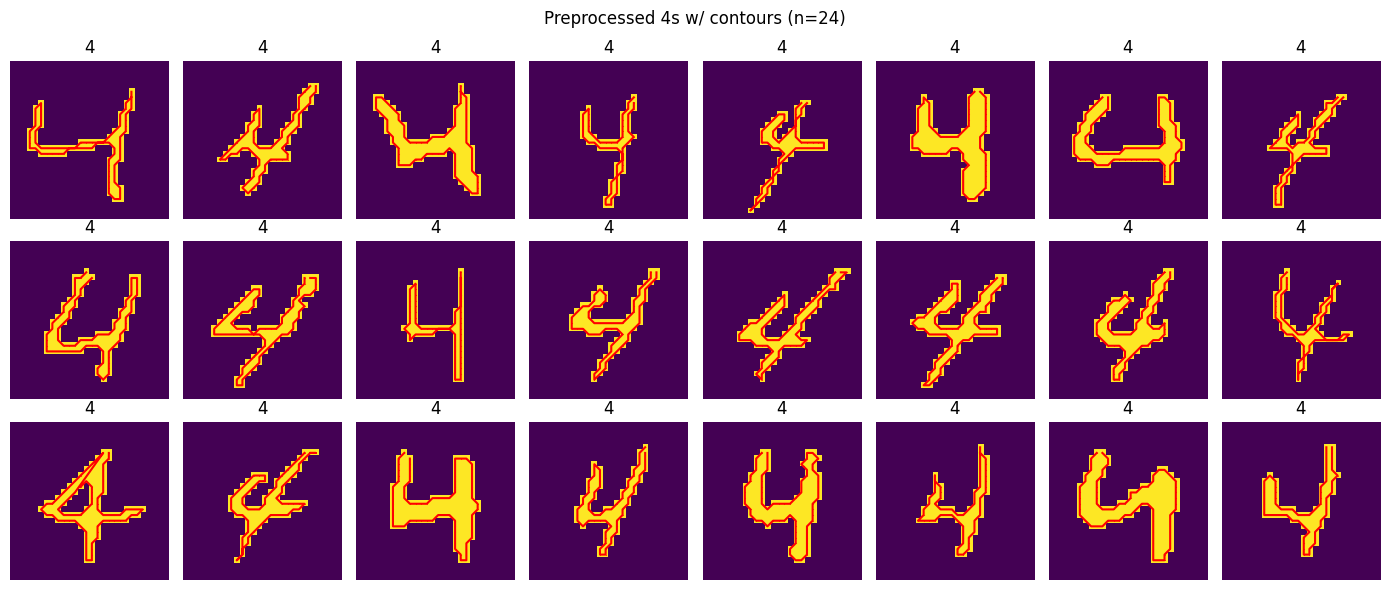

In [48]:
################################################################
############################ TEST ##############################
################################################################

cnt_p_a, cnt_p_b = test_2_1(find_contour, images_p_a, images_p_b)


Now that we are able to properly detect shape contours, we can finally compute Fourier descriptors. However, we still face a small issue. The allow a fair comparison between the Fourier descriptors we need to ensure that all descriptors have the same length.

* **Q2 (2 pts)**: Implement the function `compute_descriptor_padding` that takes as input the computed contours from before and returns the Fourier descriptors for each contour. Use `fft` ([doc](https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html#numpy.fft.fft)) from Numpy to compute the transformation. Use the `n_sample` argument to set the number of points to consider per contour. If the contour is longer than `n_sample` discard the extra points. If the contour is shorter than `n_sample`, use 0 paddings. Make sure that the first element of the descriptor represent the continuous component in the frequency domain.

In [49]:
def compute_descriptor_padding(contours: np.ndarray, n_samples: int = 11):
    """
    Compute Fourier descriptors of input images
    
    Args
    ----
    contours: list of np.ndarray
        List of N arrays containing the coordinates of the contour. Each element of the 
        list is an array of 2d coordinates (K, 2) where K depends on the number of elements 
        that form the contour. 
    n_samples: int
        Number of samples to consider. If the contour length is higher, discard the remaining part. If it is shorter, add padding.
        Make sure that the first element of the descriptor represents the continuous component.

    Return
    ------
    descriptors: np.ndarray complex (N, n_samples)
        Computed complex Fourier descriptors for the given input images
    """

    N = len(contours)
    # Look for the number of contours
    descriptors = np.zeros((N, n_samples), dtype=np.complex128)

    contours = [x[:n_samples] for x in contours if len(x) >= n_samples]

    contours = [np.pad(x, ((0, n_samples - len(x)), (0, 0)), mode='constant', constant_values=0) for x in contours]

    contours = [x[:, 0] + 1j*x[:, 1]  for x in contours]

    descriptors	 = np.array([np.fft.fft(contour) for contour in contours])

    return descriptors


The code below uses the `plot_features` function to display the computed Fourier descriptors. We display the real, imaginary, and absolute components, respectively. Each color depicts a different digit. We use 2D plots to highlight the clustering capability of the components.
* **Q3 (1 pt)**: Comment on the quality of the Fourier descriptors. Do you think they are good feature descriptors? (justify)
    * **Answer**: These fourier features are quite poor. We notice that in some features such as ``Real 5 vs 6`` and ``Real 3 vs 4`` there is significant overlap between class 0 and class 4. This overlap makes it impossible or at the very least incredibly difficult to find a good class separator. We might be able to use the ``Ìmaginary 0 vs 1`` feature to separate the classes, however we expect the classificaation error to be high since we notice a significant number of outliers in that feature space. 


* **Q4 (1 pt)**: Knowing that we used `n_samples=11` to compute the Fourier transform, what do the components 0, 1, 5, and 10 represent as frequencies? (high, medium, constant, etc.)
    * **Answer**: Component 0 in th FFT dentoes the DC constant component, 1 would be the low frequency, 5 would be the medium frequncy and 10 would represent the high frequency component.


(0 in the grapsh below are not the DC component but the first frequency component)

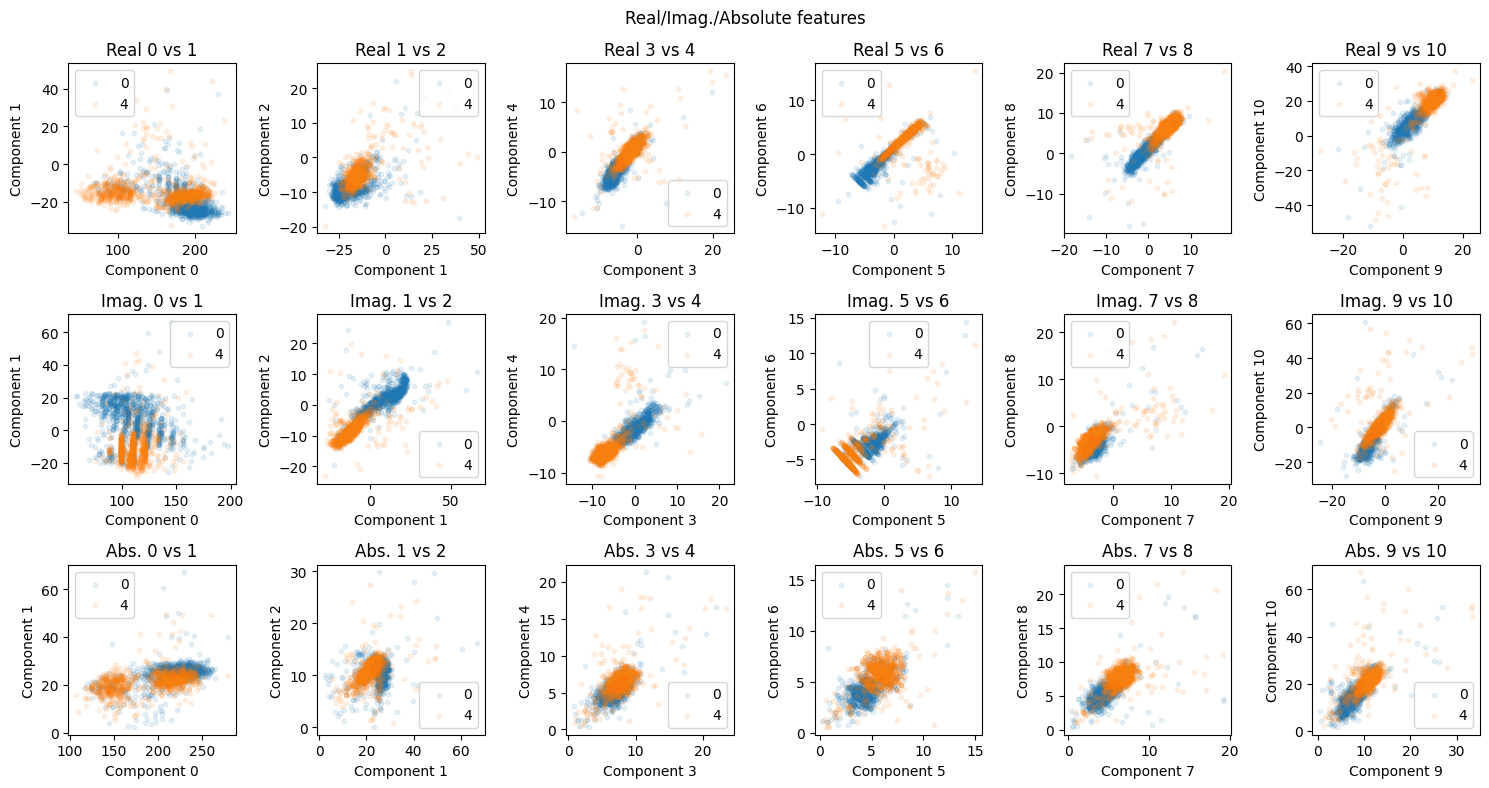

In [50]:
################################################################
############################ TEST ##############################
################################################################

test_2_1_2(compute_descriptor_padding, cnt_p_a, cnt_p_b)

As you might have realized before, the computed Fourier descriptors do not help us to find an optimal separation between the digits. This mainly comes from the fact that using 0 padding is a cheap and inefficient way to ensure homogeneity in length for descriptors. A better solution would be to ensure that we have the same number of points along the contour for each digit. To do so, we need to implement a new function that will resample the contour such that we always have the same number of points no matter the shape.

* **Q5 (2 pts)**: Implement the function `linear_interpolation` that takes as input the contours with various lengths and the wanted number of samples per contour for resampling. For each contour, resample the points such that each contour has the same length `n_samples`. We want the points to be uniformly distributed (same distance between points) along the contour. You can use for example the function `interp` ([doc](https://numpy.org/doc/stable/reference/generated/numpy.interp.html)) from Numpy to perform the interpolation. The function `display_samples` will display the contour for different lengths.

**Hint**: Think about the contour as two distinct signals x(t) and y(t) that are evaluated at different time steps $t$. Here the time steps can be seen as the Euclidean distance between consecutive samples $t_i$ = $ \sum_{j=1}^{j \leq i} \sqrt{(x_{j} - x_{j-1})^2 + (y_{j} - y_{j-1})^2}$, and $t_0 = 0$. The aim here is to resample the function at new time steps $t_i' = i * \frac{t_{N-1}}{n_{samples} + 1}$ where $n_{samples}$ is the new number of points.

In [51]:
def linear_interpolation(contours: np.ndarray, n_samples: int = 11):
    """
    Perform interpolation/resampling of the contour across n_samples.
    
    Args
    ----
    contours: list of np.ndarray
        List of N arrays containing the coordinates of the contour. Each element of the 
        list is an array of 2d coordinates (K, 2) where K depends on the number of elements 
        that form the contour. 
    n_samples: int
        Number of samples to consider along the contour.

    Return
    ------
    contours_inter: np.ndarray (N, n_samples, 2)
        Interpolated contour with n_samples
    """

    N = len(contours)
    contours_inter = np.zeros((N, n_samples, 2))

    for i, contour in enumerate(contours):

        # Skip empty contours
        # Adding this in case contours are empty when scaling too small (exercise 2.3.4), but shouldn't happen
        if len(contour) < 2:
            contours_inter[i]=np.zeros((n_samples, 2))
            continue

        # Compute distance between points (arc length)
        deltas = np.diff(contour, axis=0)
        dists = np.hypot(deltas[:, 0], deltas[:, 1])
        arc_length = np.concatenate([[0], np.cumsum(dists)])
        arc_length /= arc_length[-1]  # Normalize to [0, 1]

        # Interpolate both x and y along normalized arc length
        t = np.linspace(0, 1, n_samples)
        x_new = np.interp(t, arc_length, contour[:, 0])
        y_new = np.interp(t, arc_length, contour[:, 1])
        contours_inter[i] = np.stack((x_new, y_new), axis=1)

    return contours_inter


In [52]:
# def hybrid_interpolation(contours: np.ndarray, n_samples: int = 80):
#     N = len(contours)
#     # Look for the number of contours
#     descriptors = np.zeros((N, n_samples), dtype=np.complex128)
    

#     contours_too_much = [x for x in contours if len(x) >= n_samples]
#     contours_intep = linear_interpolation(contours_too_much, n_samples=n_samples)

#     contours_padded = [np.pad(x, ((0, n_samples - len(x)), (0, 0)), mode='constant', constant_values=0) for x in contours if len(x) < n_samples]


#     contours_intep = np.concatenate((contours_intep, contours_padded), axis=0)


#     return contours_intep




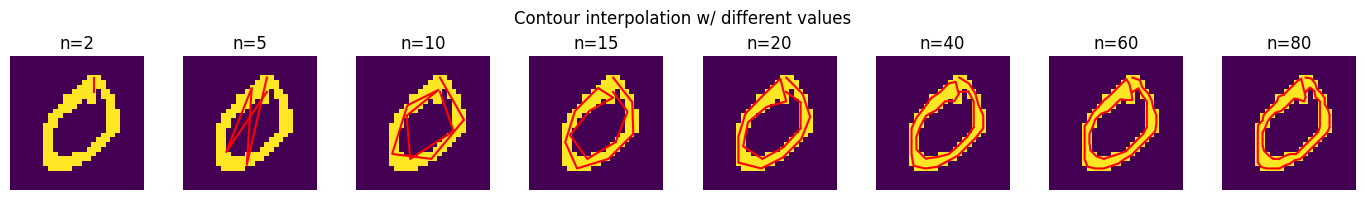

In [53]:
################################################################
############################ TEST ##############################
################################################################

test_2_1_5(linear_interpolation, cnt_p_a, images_p_a)

Now that we have implemented our resampling approach we can revisualize the clustering efficiency of our descriptors.

* **Q6 (1 pt)**: Comment on the quality of the descriptors. Is it better than before? is there a frequency/component that appears to work better? Does it make sense?
    * **Answer**: After resampling, the 11 contour points are evenly spaced around the shape, unlike before when they were just a truncated segment. This uniform distribution captures the full geometry better, making the Fourier descriptors more informative. High-frequency components, which capture fine details, become especially useful and help distinguish 0s and 4s which are similar in their broad shape but different in the details. This is what we see when looking at the ``Imaginary 7 vs 8`` feature. What is also interesting to note is that some of the "absolute" features also start to be useful, which would make the classification rotationally invariant. For example feature ``Abs. 9 vs 10`` shows good class separation.

In [54]:

# feat_a, feat_b = test_2_1_6(compute_descriptor_padding, hybrid_interpolation, cnt_p_a, cnt_p_b, n_samples=11)

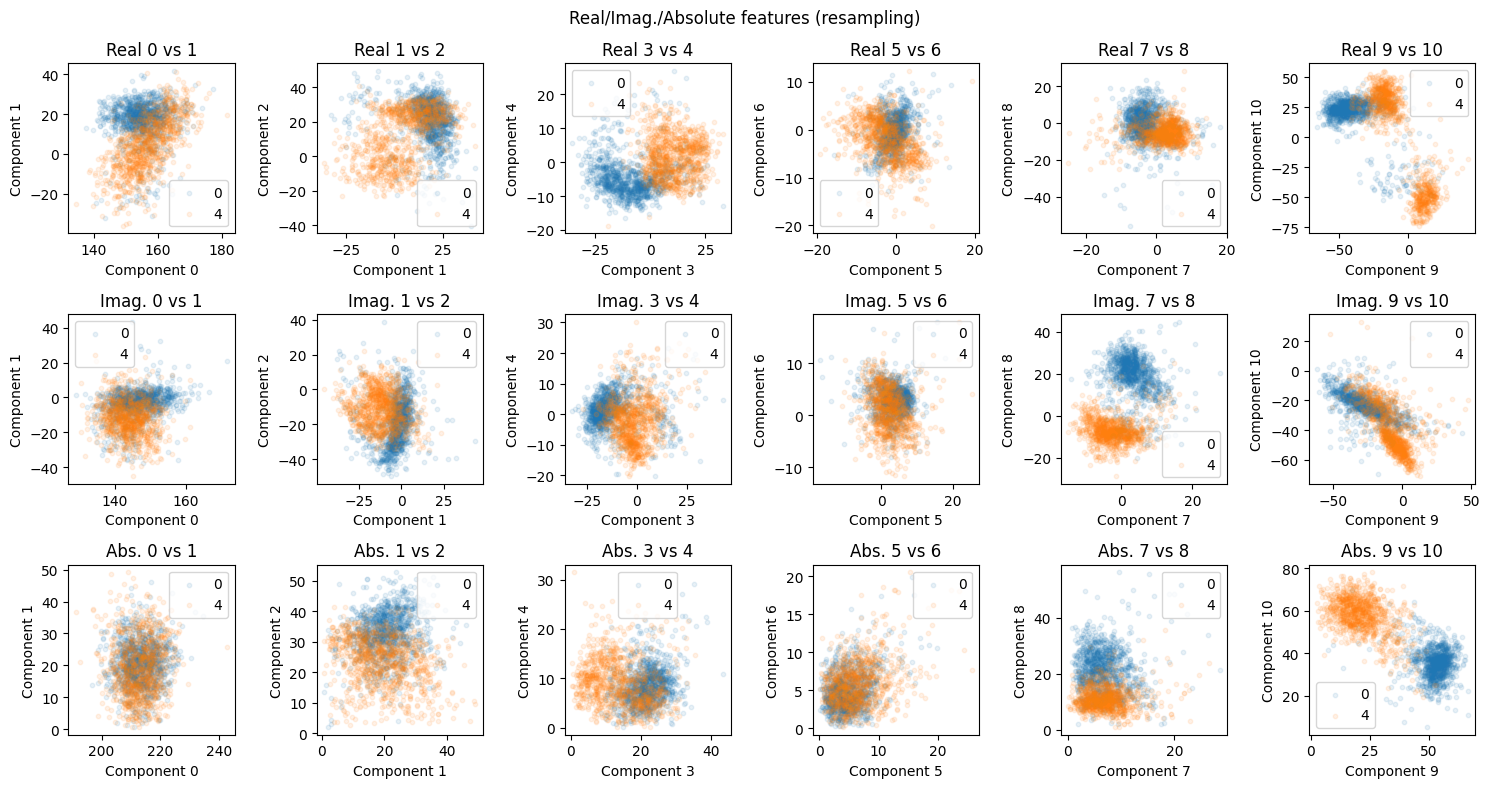

In [55]:
################################################################
############################ TEST ##############################
################################################################

feat_a, feat_b = test_2_1_6(compute_descriptor_padding, linear_interpolation, cnt_p_a, cnt_p_b, n_samples=11)

In [56]:

# _, _ = test_2_1_6(compute_descriptor_padding, linear_interpolation, cnt_p_a, cnt_p_b, n_samples=15)

## 2.2. Reconstruction (2 pts)

For this part, we will now try to go the other way. Given a Fourier descriptor we will try to retrieve the original shape. 
* **Q1 (1 pt)** Implement the function `compute_reverse_descriptor` that takes as input a single descriptor and reverses it to x and y coordinates given a number of samples `n_samples`. Use the function `ifft` ([doc](https://numpy.org/doc/stable/reference/generated/numpy.fft.ifft.html)) from Numpy.

In [57]:
def compute_reverse_descriptor(descriptor: np.ndarray, n_samples: int = 11):
    """
    Reverse a Fourier descriptor to xy coordinates given a number of samples.
    
    Args
    ----
    descriptor: np.ndarray (D,)
        Complex descriptor of length D.
    n_samples: int
        Number of samples to consider to reverse transformation.

    Return
    ------
    x: np.ndarray complex (n_samples,)
        x coordinates of the contour
    y: np.ndarray complex (n_samples,)
        y coordinates of the contour
    """

    x = np.zeros(n_samples)
    y = np.zeros(n_samples)
    
    comp = np.fft.ifft(descriptor)
    x = np.real(comp)
    y = np.imag(comp)


    return x, y


With the function `plot_reconstruction` we plot an example of the reconstruction of the digits. We display the result as we progressively add more frequencies. We start with the first component (component 0) and then add frequency pairs from low to high frequencies.

* **Q2 (1 pt)**: Based on your observation, do you think 11 samples are enough to properly describe the digits below? (justify)
    * **Answer**: No we think that 11 samples is not enough to properly _describe_ the digits. For digit 0, we see that it does an ok job, but without the image of the digit for context it could be difficult to guess what digit it was meant to be. For digit 4 it barely outlines the edges and again, without the context of the image below, it would be difficult to visually recognize what the digit is meant to be. However, 11 samples are likely enough to _discern_ 0s from 4s, because the shape of the contours, even with rough sampling, are qualitatively different enough. So overall, 11 samples are enough to separate 0s from 4s, but not necessarily to tell what the digits are. It is worth noting that if we only had external contours, the 11 points would have been less spread around the contour and probably would have made the digits more identifiable. However, since an important qualitative difference between 0s and 4s is that 0s usually have an internal contour and 4s usually do not, we felt it was still relevant to keep our implementation.

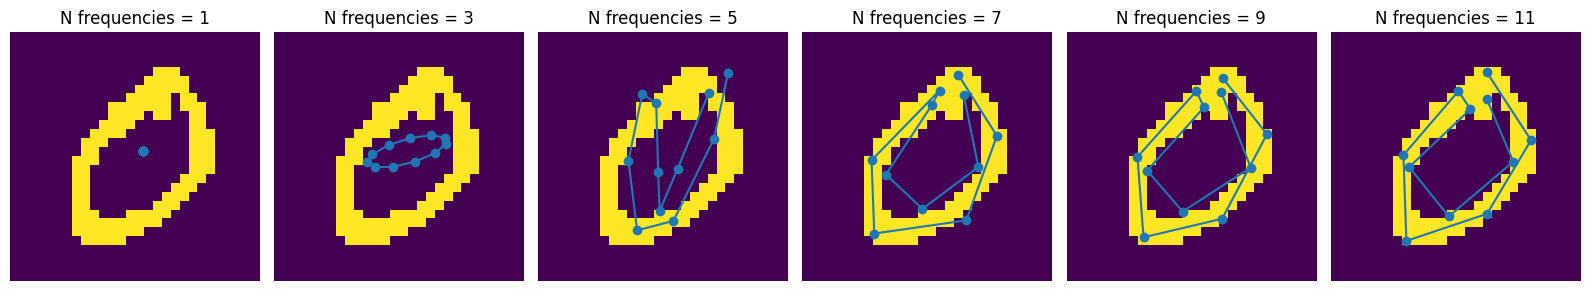

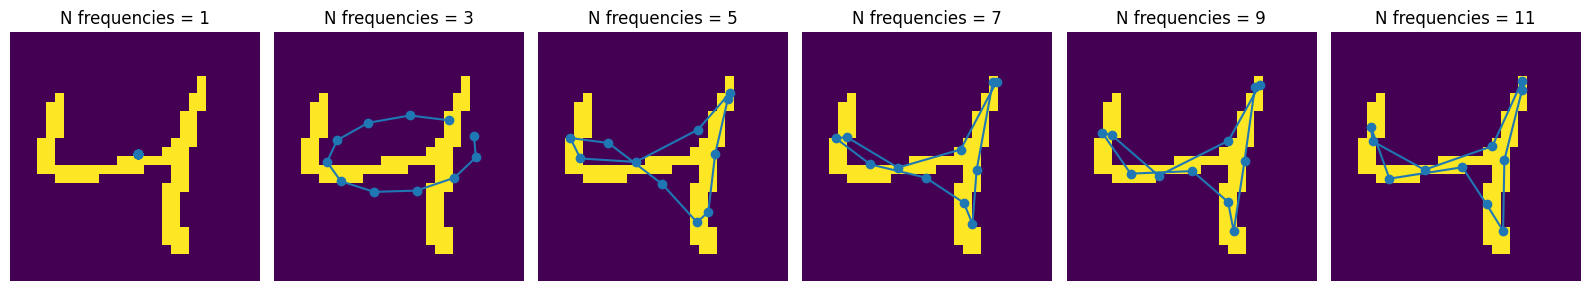

In [58]:
################################################################
############################ TEST ##############################
################################################################
test_2_2(images_p_a , images_p_b, feat_a, feat_b, compute_reverse_descriptor)

## 2.3. Invariance (6 pts)

For the last part with Fourier descriptors, we will check for descriptors invariance. As seen in class, if handled properly Fourier descriptors can be invariant to translation, rotation, and scaling.

* **Q1 (3 pts)**: Implement the functions `apply_rotation`, `apply_scaling`, and `apply_translate` to apply random rotation, scaling, and translation to input images. For scaling and translation, we recommend avoiding large values where the digits are cropped (out of frame). You can use the `random` package ([doc](https://numpy.org/doc/1.16/reference/routines.random.html)) from Numpy to generate random values.

In [59]:
import skimage
from skimage.morphology import dilation, disk
def apply_rotation(img: np.ndarray):
    """
    Apply random rotation to input the image
    
    Args
    ----
    image: np.ndarray (28, 28)
        Source images
        
    Return
    ------
    rotated: np.ndarray (28, 28)
        Rotated source images
    """

    #rand_angle = np.random.uniform(0, 360)*0
    rand_angle = np.random.uniform(0, 360)

    # rotated = rotate(img, rand_angle)
    # in the rotation invariant part, during the test, the rotated image was completely black
    # this was probably an interpolation artifact
    # setting the order to 0 (by default, it's 1) which fixed the problem
    # order 1 = bilinear interpolation, uses weighted average of the four nearest pixels in the original image
    # order 0 = nearest-neighbor interpolation, uses the value of the nearest pixel in the original image
    rotated = rotate(img, angle=rand_angle, order=5)
    rotated = rotated > 0.5*max(rotated.flatten())
    rotated = rotated.astype(np.uint8)
    # However the rotated image is "less smooth". So I closed it.
    #structuring_element = disk(1)  
    #smoothed = closing(rotated, structuring_element)
    return rotated


def apply_scaling(img: np.ndarray):
    """
    Apply random scaling to input image
    
    Args
    ----
    image: np.ndarray (28, 28)
        Source images
        
    Return
    ------
    scaled: np.ndarray (28, 28)
        Scaled source images
    """
    
    scaled = np.zeros_like(img)
    
    #zoom_factor = np.random.random() * 2
    #setting minimum to 0.3 so that the image is not too small (contour ~ 0)
    zoom_factor = np.random.uniform(0.3, 2.0)
    
    # Compute the new dimensions
    original_shape = img.shape
    new_shape = (int(original_shape[0] * zoom_factor), int(original_shape[1] * zoom_factor))

    # Resize the image to the new dimensions
    # made order=0 to avoid interpolation artifacts
    # closed the scaled image to make it smoother
    
    #scaled_not_smoothed = resize(img, new_shape, order = 0)
    #structuring_element = disk(1)  
    #scaled = closing(scaled_not_smoothed, structuring_element)

    scaled = resize(img, new_shape, order=5)
    scaled = scaled > 0.5*max(scaled.flatten())


    if scaled.shape[0] > 28 or scaled.shape[1] > 28:
        new_center_x = scaled.shape[0] // 2
        new_center_y = scaled.shape[1] // 2

        scaled = scaled[new_center_x-14:new_center_x+14, new_center_y-14:new_center_y+14]
    else:
        padding_needed_x = (28 - scaled.shape[0]) // 2
        padding_needed_y = (28 - scaled.shape[1]) // 2

        remainder_x = (28 - scaled.shape[0]) % 2
        remainder_y = (28 - scaled.shape[1]) % 2

        scaled = np.pad(scaled, ((padding_needed_x, padding_needed_x + remainder_x), (padding_needed_y, padding_needed_y+remainder_y)), mode='constant')

    
    assert scaled.shape[0] == 28 and scaled.shape[1] == 28, f"The scaled image is not 28x28. It is {scaled.shape[0]}x{scaled.shape[1]} "

    return scaled

def apply_translate(img: np.ndarray):
    """
    Apply random x and y translation to input image
    
    Args
    ----
    image: np.ndarray (28, 28)
        Source images
        
    Return
    ------
    translated: np.ndarray (28, 28)
        Translated source images
    """
    
    translated = np.zeros_like(img)

    del_x = np.random.uniform(-5, 5)
    del_y = np.random.uniform(-5, 5)
    transformation_matrix = np.array([[1, 0, del_x], [0, 1, del_y]])

    translated = cv2.warpAffine(img, transformation_matrix, (img.shape[0], img.shape[1]), flags=cv2.INTER_NEAREST, borderValue=0)

    return translated


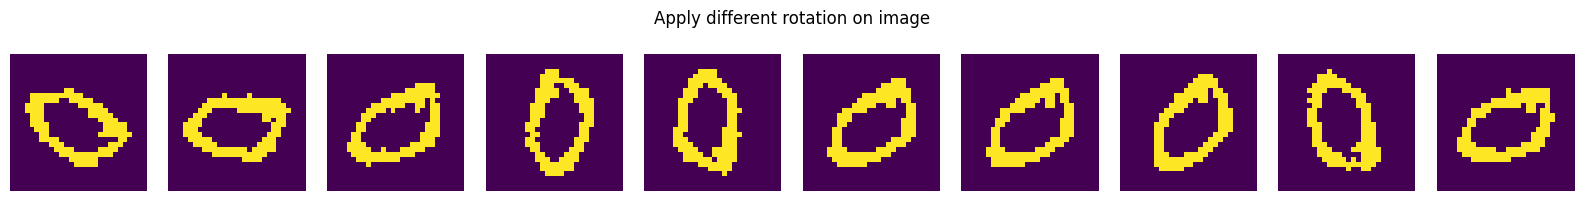

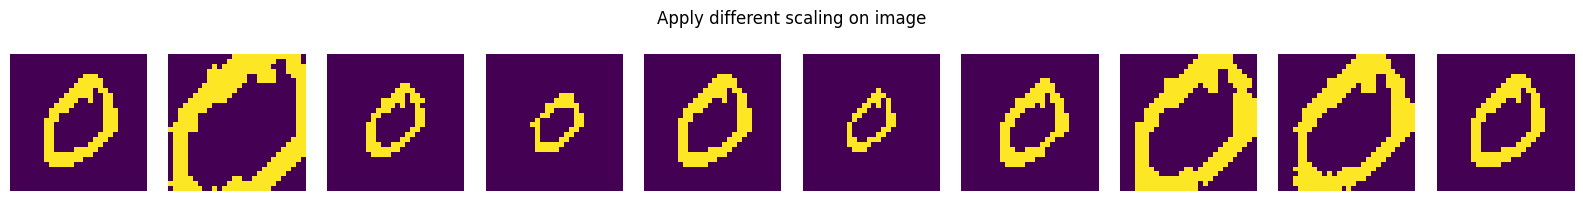

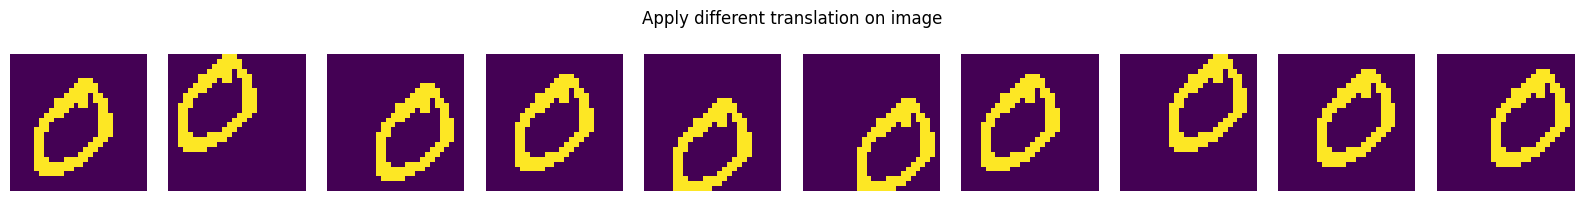

In [60]:
################################################################
############################ TEST ##############################
################################################################

test_2_3(apply_rotation, apply_scaling, apply_translate, images_p_a[0])

Now that we implemented our transformation, we can test for feature invariance. To assess the robustness of the Fourier descriptors to image transformations, we compute the error between the original descriptors (before transformation) to the one after transformation. 

* **Q2 (1 pt)**: Complet the function `translation_invariant` to make the Fourier deciptor invariant to translation. Does the error decrease after treatment for translation invariance? Is it null, if not why?
    * **Answer**: The error is not quite zero, but it is definitely reduced after making the features translation invariant, confirming that the transformation successfully accounts for translational differences. The error is nonzero because 1- for some of the larger image objects, translations may cause parts of the digit to be cut off by the image borders, and 2- our implementation allows translations by a subpixel value, which is then rounded to the nearest pixel. Thus, because of the dicrete nature of pixels, the translations may not be identical to the image shifted.

In [61]:
def translation_invariant(features):
    """
    Make input Fourier descriptors invariant to translation.

    Args
    ----
    features: np.ndarray (N, D)
        The Fourier descriptors of N images over D features.

    Return
    ------
    features_inv: np.ndarray (N, K)
        The Fourier descriptors invariant to translation of N images 
        over K (K <= N) features.
    """

    # Set default values
    features_inv = np.zeros_like(features)
    
    #Get rid of the DC component since that is what determines the center position of the image
    features_inv = features[:, 1:]
        
    return features_inv

Translation error: 4.41
Corrected translation error: 0.58


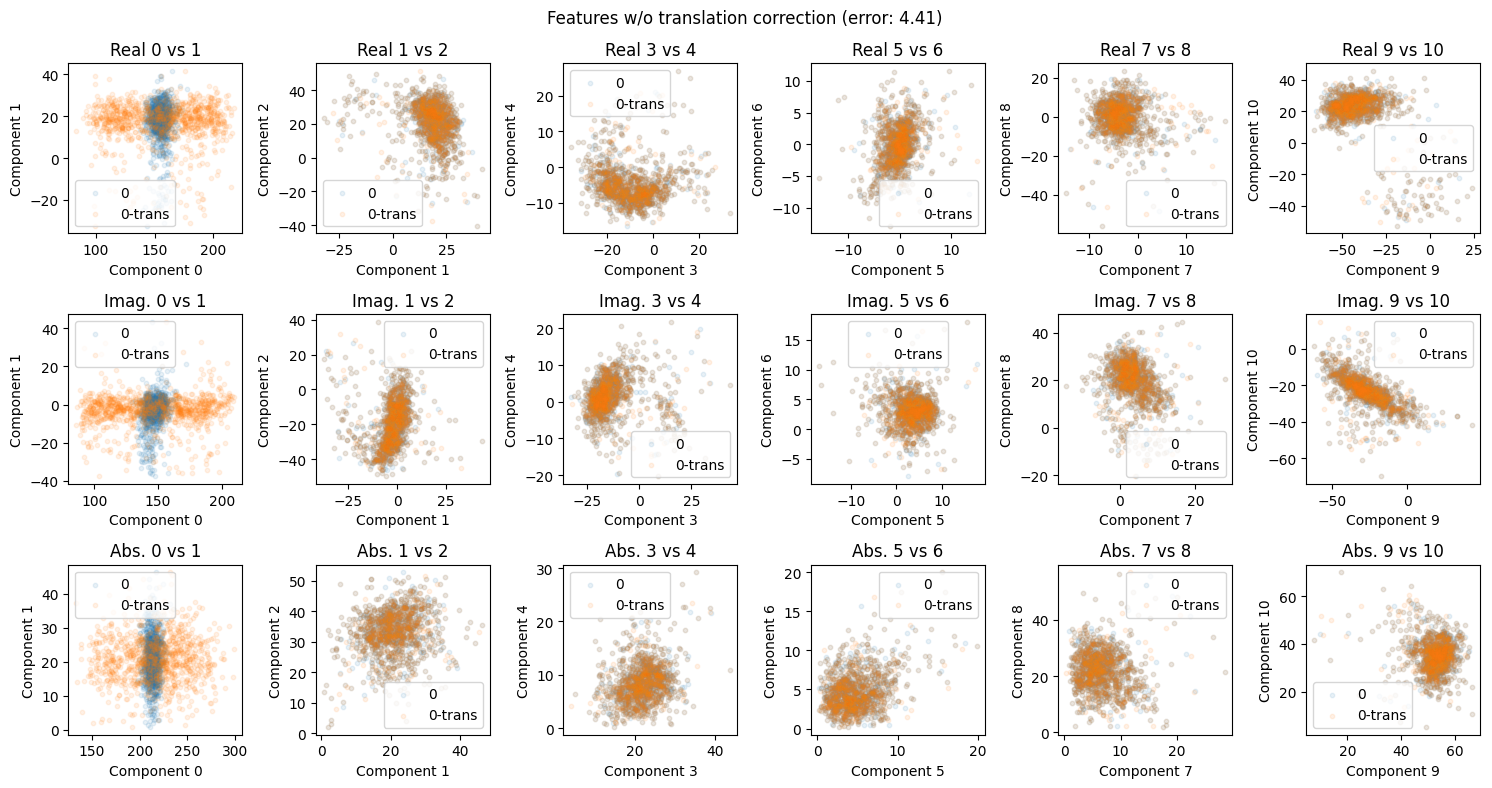

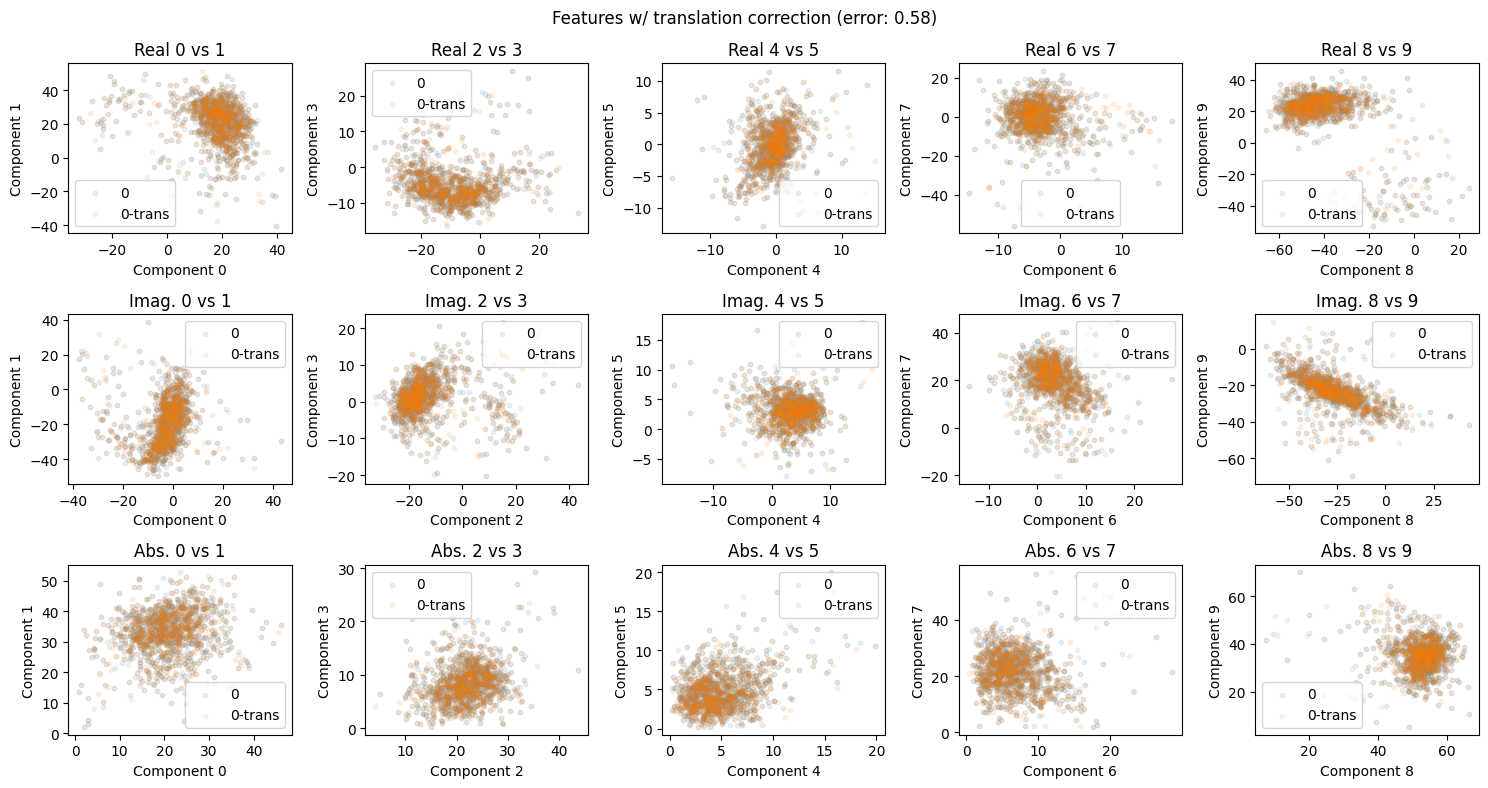

In [62]:
################################################################
############################ TEST ##############################
################################################################

feat_t_a = test_2_3_2(translation_invariant, find_contour, apply_translate, compute_descriptor_padding, linear_interpolation,images_p_a, feat_a)

* **Q3 (1 pt)**: Complet the function `rotation_invariant` to make the Fourier deciptor invariant to rotation. Does the error decrease after treatment for rotation invariance? Do you think that selecting specific rotation angles might help the error to decrease even lower?
    * **Answer**: Again like with the translation invariance above, the error is lowered when applying rotation invariance to the features. However we notice that the error is still relatively high (~4). We think that this is also due to interpolation artifacts arising from the discreteness of pixels. 
    If we could do this rotation with perfect sub-pixel accuracy then the contour traced before and after the transformation would be rotated versions of each other. However, because of the interpolation and the thresholding, we have no gaurentee that the contour traced after the transformation is just a rotated version of the inital contour. And since our Fourier descriptors depend of the absolute position of the contour points, simply neglecting the phase will not be enought to bring the error fully to 0. 
    In a controlled setting, selecting "nicer" angles like multiples of 90° could reduce interpolation artifacts because they align better with the pixel grid, potentially leading to a lower error. However, we want these features to be general across any type of rotation, since we do not know in advance what rotation will be present in the image. Therefore, for realistic applications, we don't think that selecting specific rotations will improve the error.

In [63]:
def rotation_invariant(features):
    """
    Make input Fourier descriptors invariant to rotation.

    Args
    ----
    features: np.ndarray (N, D)
        The Fourier descriptors of N images over D features.

    Return
    ------
    features_inv: np.ndarray (N, K)
        The Fourier descriptors invariant to rotation of N images 
        over K (K <= N) features.
    """

    # Set default values
    #features_inv = np.zeros_like(features)
    #print("no transformation")
    

    features_inv = np.absolute(features)

    # ------------------
    # Your code here ... 
    # ------------------

    return features_inv

Rotation error: 12.62
Corrected rotation error: 4.83


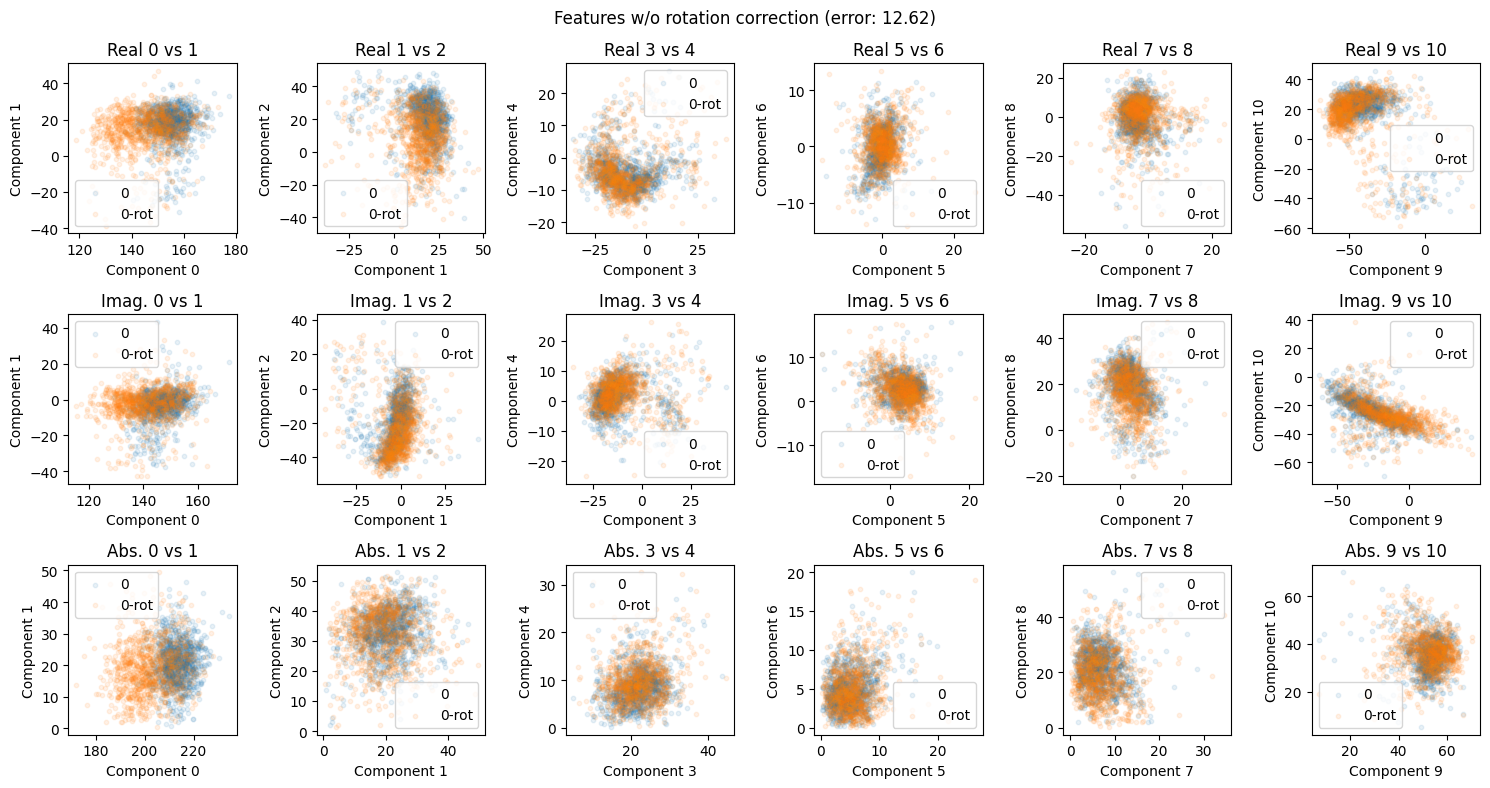

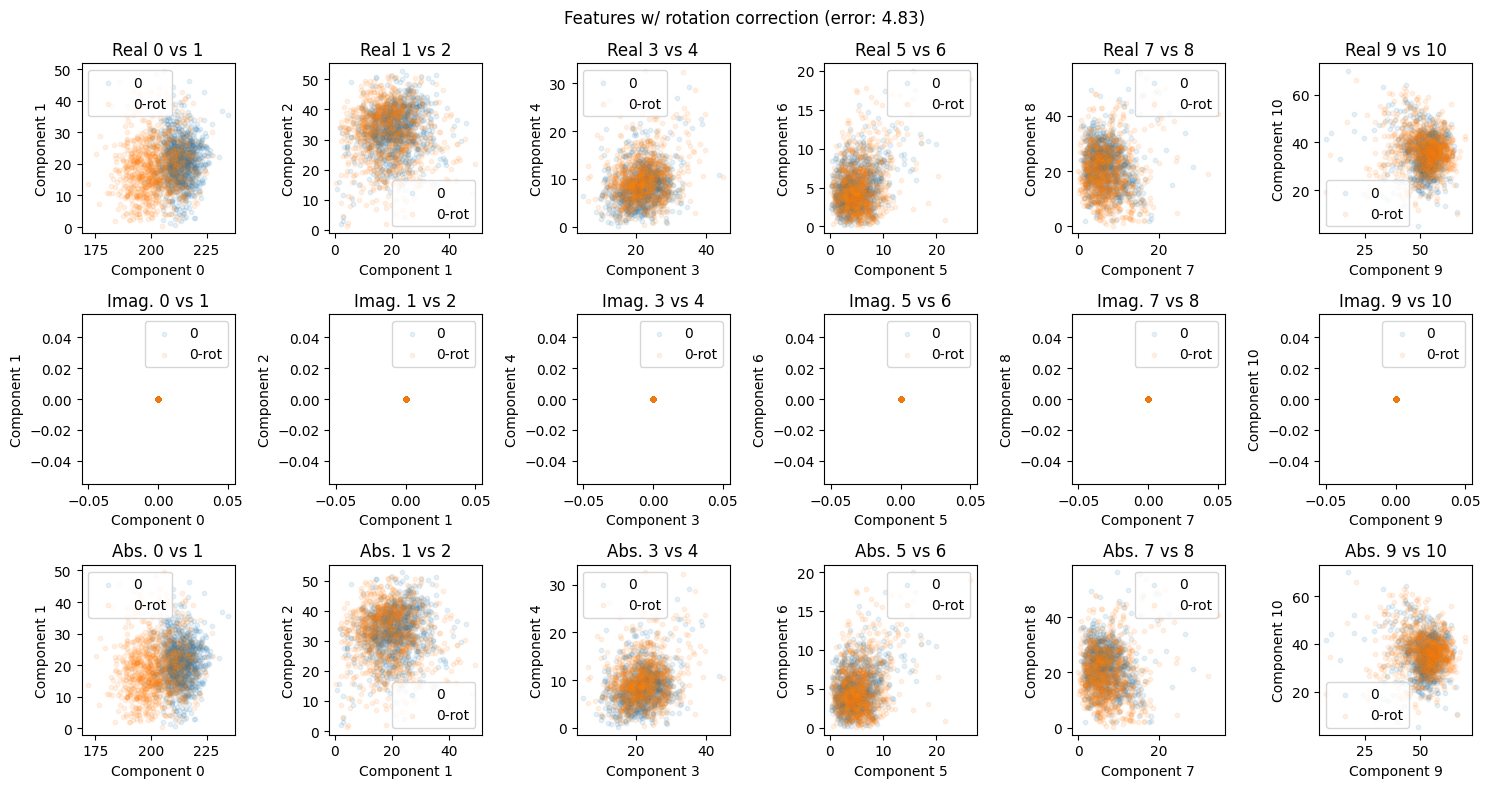

In [64]:
################################################################
############################ TEST ##############################
################################################################
test_2_3_3(rotation_invariant, find_contour, apply_rotation, compute_descriptor_padding, linear_interpolation,images_p_a, feat_a)

* **Q4 (1 pt)**: Complet the function `scaling_invariant` to make the Fourier deciptor invariant to scaling. Does the error decrease after treatment for scaling invariance? Is it null? Why?
    * **Answer**: The error decreases after applying scaling invariance, but it isn't fully zero. In theory, scaling affects the magnitude of the Fourier descriptors, so dividing the descriptors by the magnitude of the first non-zero coefficient removes this effect and makes the descriptors invariant to scale. However, in practice, again partly due to interpolation artifacts during the transformation, the error is nonzero. Additionally, if the image is scaled too large, some parts of the shape might be cut off by the borders, and if scaled too small, there might be insufficient contour information for accurate descriptor computation.

In [65]:
def scaling_invariant(features):
    """
    Make input Fourier descriptors invariant to scaling.

    Args
    ----
    features: np.ndarray (N, D)
        The Fourier descriptors of N images over D features.

    Return
    ------
    features_inv: np.ndarray (N, K)
        The Fourier descriptors invariant to scaling of N images 
        over K (K <= N) features.
    """

    # Set default values
    features_inv = np.zeros_like(features)

    # Normalize each feature set by the magnitude of the first non-zero descriptor
    features_inv = features / np.abs(features[:, 1:2])

    # ------------------
    # Your code here ... 
    # ------------------

    return features_inv

Scaling error: 4.41
Corrected scaling error: 1.10


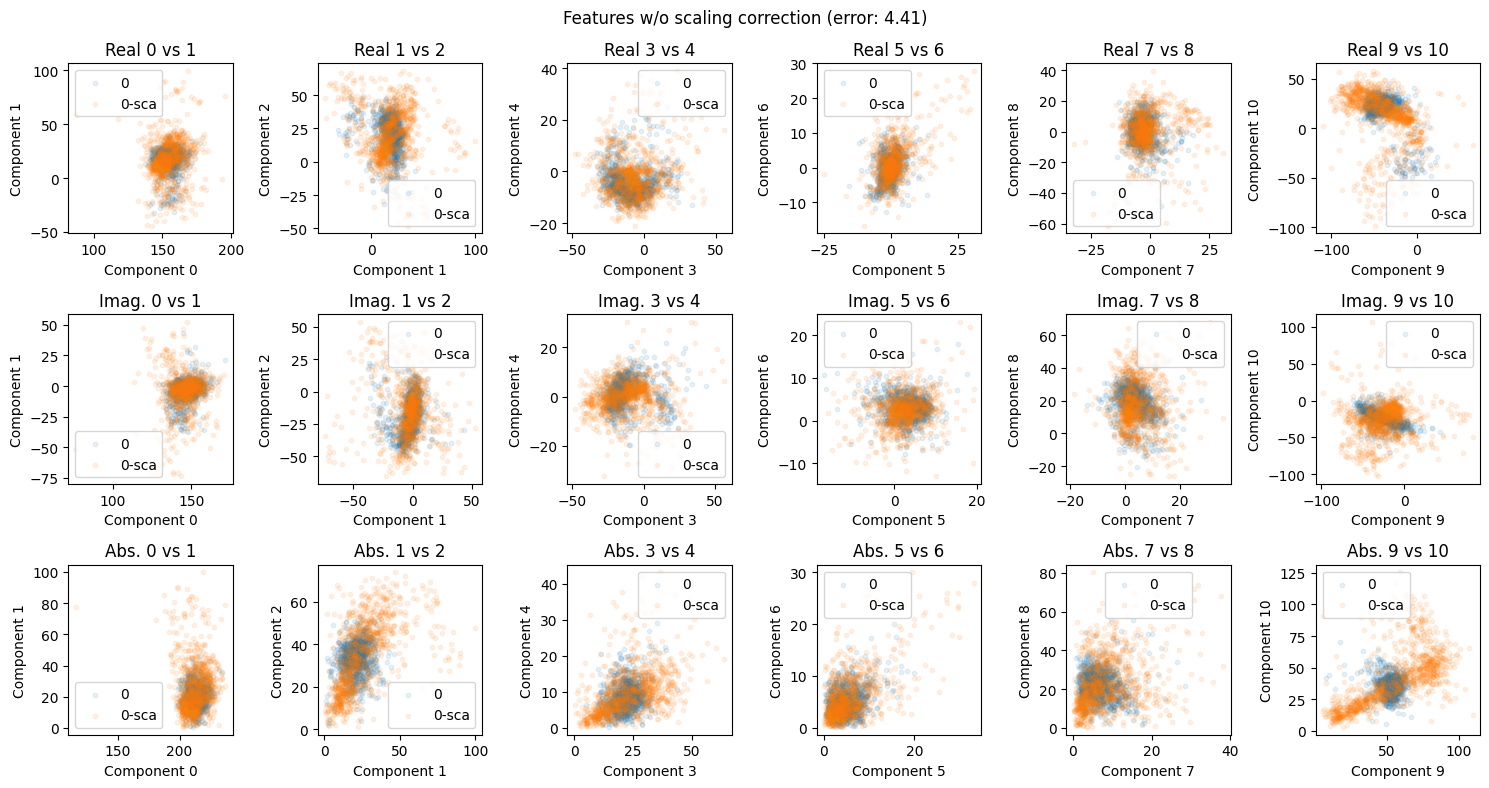

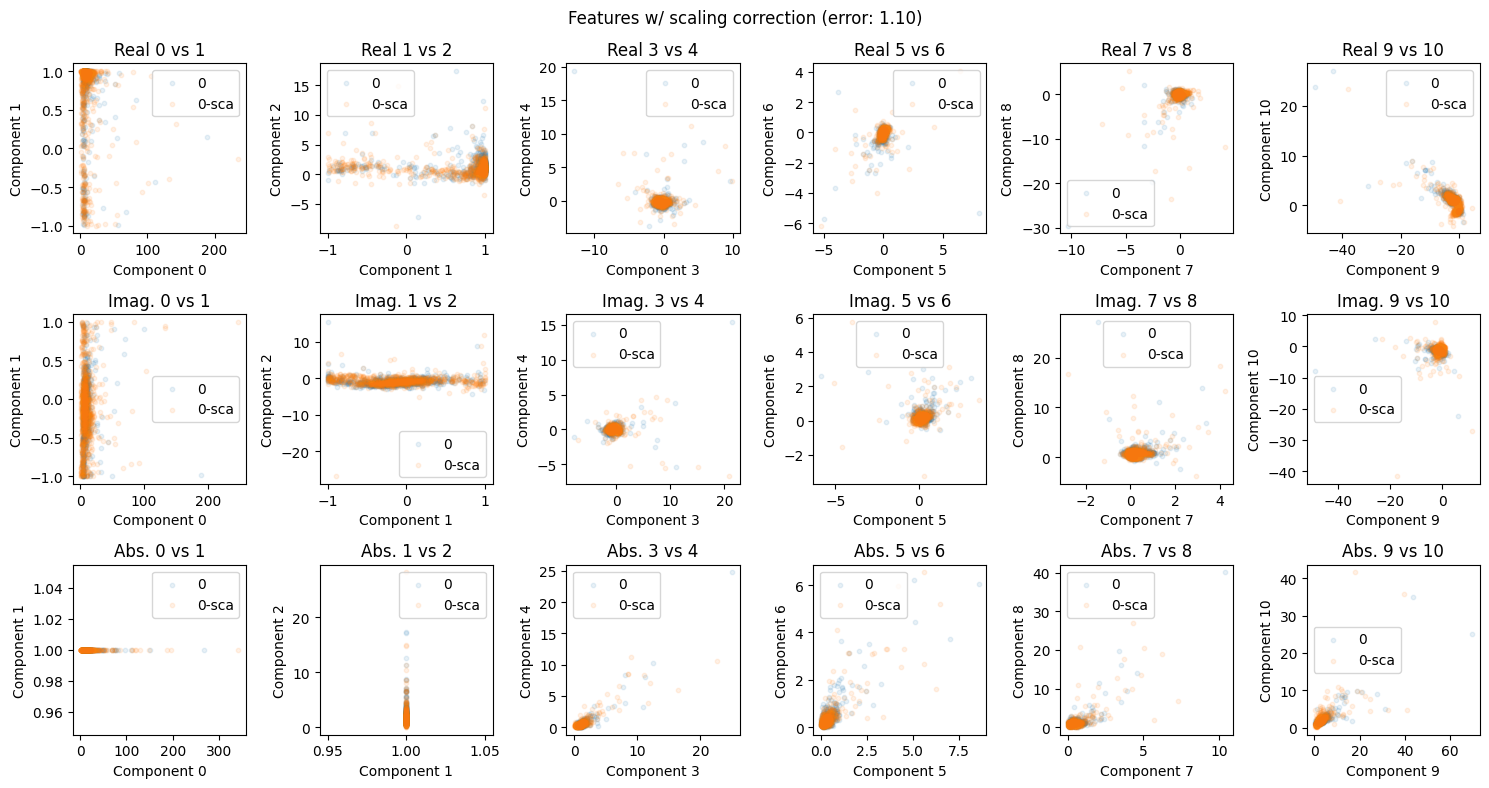

In [66]:
################################################################
############################ TEST ##############################
################################################################

test_2_3_4(scaling_invariant, find_contour, apply_scaling, compute_descriptor_padding, linear_interpolation,images_p_a, feat_t_a, feat_a)

---
# PART 3 - Other descriptors [8 pts]

## 3.1 Distance map (5 pts)

In this part, we will learn how to use a distance map as a feature descriptor. 

* **Q1 (1 pt)**: To compute a distance map we first need a reference pattern. Complete the function `reference_pattern`. The function takes as input a list of images and computes the reference pattern as the average of all shapes.

In [67]:
def reference_pattern(imgs):
    """
    Compute the reference pattern for a given set of images. The reference pattern 
    is estimated as the average of all images of the same pattern.

    Args
    ----
    imgs: np.ndarray (N, 28, 28)
        Source images
        
    Return
    ------
    pattern: np.ndarray (28, 28)
        Thresholded reference pattern that is the average of all shapes.
    """

    # Initialize pattern
    pattern = np.zeros((imgs[0].shape[0], imgs[0].shape[1]))

    pattern = np.mean(imgs, axis=0)

    # Thresholding
    pattern = pattern > 0.30
    pattern = pattern.astype(np.uint8)

    return pattern

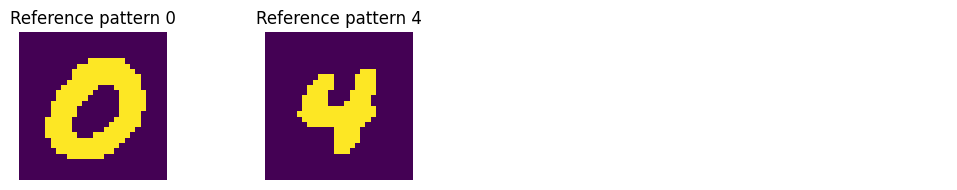

In [68]:
################################################################
############################ TEST ##############################
################################################################

pattern_a, pattern_b = test_3_1(reference_pattern, images_p_a, images_p_b)

* **Q2 (2 pts)**: The next part will be to compute a distance map from the generated pattern. By pre-computing the distance map we can speedup the inference time. Complete the function `compute_distance_map`. We expect the values of the map to represent the distances to the closest pattern contour. If needed, can take advantage of the functions you wrote in PART2 to detect and resample contours.

In [69]:
def compute_distance_map(pattern: np.ndarray):
    """
    Compute the distance map for the given pattern. The values of the map are computed as 
    the distance to the closest pattern contour.

    Args
    ----
    pattern: np.ndarray (28, 28)
        Pattern to process

    Return
    ------
    distance_map: np.ndarray (28, 28)
        Distance map where each entry is the distance to the closest pattern contour (shortest 
        distance to pattern)
    """
    
    # Detect the contour of the pattern
    contours = find_contour(np.expand_dims(pattern, axis = 0))[0]

    # Resample the contour points
    # n_samples = 100 works
    resampled_contour = linear_interpolation([contours], n_samples = 100)[0] 
    
    # Compute the distance map

    # Create a grid of all pixel coordinates in the image
    h, w = pattern.shape
    x, y = np.meshgrid(np.arange(w), np.arange(h), indexing='ij')
    pixel_coords = np.stack((y.ravel(), x.ravel()), axis=1)
    
    # Compute distances from each pixel to the resampled contour points
    distances = euclidean_distances(pixel_coords, resampled_contour)

    # Find the minimum distance for each pixel
    min_distances = distances.min(axis=1)

    distance_map = min_distances.reshape(h, w)

    return distance_map

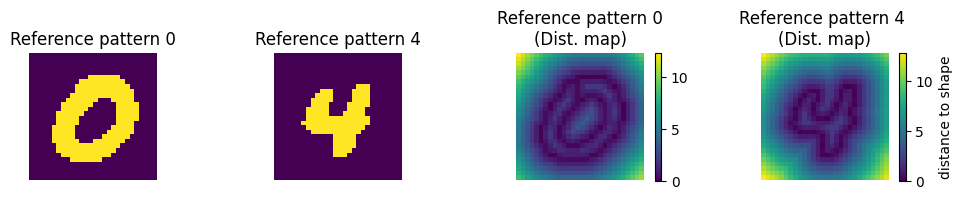

In [70]:
################################################################
############################ TEST ##############################
################################################################

map_a, map_b = test_3_1_2(compute_distance_map, pattern_a, pattern_b)

* **Q3 (2 pts)**: For the last part, implement the function `compute_distance` that uses the precomputed distance map to evaluate the distance to all images. Note that for each image you should return the average of distances. As before, for each digit, you can compute the contour and estimate the point-to-point distance by evaluating the distance map at the xy contour coordinates.

In [71]:
def compute_distance(imgs, d_map):
    """
    Compute the distances for each image with respect to the reference pattern using the precomputed 
    distance map. The final distance is the average of all distances from the image's contour points 
    to the reference pattern.

    Args
    ----
    imgs: np.ndarray (N, 28, 28)
        Source images
    d_map: np.ndarray (28, 28)
        The precomputed distance map where each entry is the distance to the closest pattern contour 
        (shortest distance to pattern)
    
    Return
    ------
    dist: np.ndarray (N, )
        Averaged distance to pattern for each input image.
    """
    

    # Default values
    dist = np.zeros(len(imgs))

    contours = find_contour(imgs)
    
    #delete later, plots everything upside down but seems okay
    """for i, img in enumerate(imgs[:2]):
        plt.imshow(img, cmap='gray', origin='lower')
        plt.plot(contours[i][:, 0], contours[i][:, 1], '-r') 
        plt.title(f"Image {i} with Contour")
        plt.axis('off')
        plt.show()"""

    #delete later, plots everything upside down but seems okay
    """for i, contour in enumerate(contours[:2]): 
        plt.imshow(d_map, cmap='viridis', origin='lower')
        plt.plot(contour[:, 0], contour[:, 1], '-r')  
        plt.title(f"Contour {i} Overlaid on Distance Map")
        plt.colorbar()
        plt.axis('off')
        plt.show()"""
    
    for i in range(len(imgs)):
        contour = contours[i]
        contour = np.round(contour).astype(int)
        distances = d_map[contour[:, 1], contour[:, 0]]
        #distances = d_map[contour[:, 0], contour[:, 1]]
        dist[i] = np.mean(distances)

    
    return dist
    

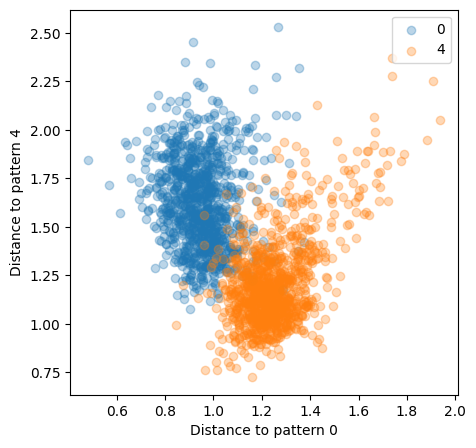

In [72]:
################################################################
############################ TEST ##############################
################################################################

test_3_1_3(compute_distance, images_p_a, images_p_b, map_a, map_b)

## 3.2 Others (3 pts)

For the last part of the lab, we will compute other various visual features. 

* **Q1: (2 pts)**: Implement the function `compute_features` that estimates the digit's perimeter, area, compacity, and rectangularity. You can use the lecture to look for the definition of each feature. To help you with this task we strongly recommend using the `regionprops` ([doc](https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops)) from scikit-image.
* **Q2: (1 pt)**: Which feature(s) seem(s) to show the best results to distinguish between both digits? (justify)
    * **Answer**: We think the compacity and the rectangularity would be the best features to distinguish between both digits. If we just considered compacity in isolation, we wouldn't be able to easily distingush the classes since there seems to be significant overlap in the compacity values. However when we also consider the Rectangularity (defined as the ratio between the area of the shape to its bounding box), we can see that we get some good class separation. We think we could use a quadratic decision boundary to separate the digits with minimal classification error.

In [73]:
def compute_features(imgs: np.ndarray):
    """
    Compute compacity for each input image.
    
    Args
    ----
    imgs: np.ndarray (N, 28, 28)
        Source images
        
    Return
    ------
    f_peri: np.ndarray (N,)
        Estimated perimeter length for each image
    f_area: np.ndarray (N,)
        Estimated area for each image
    f_comp: np.ndarray (N,)
        Estimated compacity for each image
    f_rect: np.ndarray (N,)
        Estimated rectangularity for each image
    """

    f_peri = np.zeros(len(imgs))
    f_area = np.zeros(len(imgs))
    f_comp = np.zeros(len(imgs))
    f_rect = np.zeros(len(imgs))

    contours = find_contour(imgs)

    for i, img in enumerate(imgs):
        f_area[i] = np.sum(img > 0) 

        f_peri[i] = np.sum(np.sqrt(np.sum(np.diff(contours[i], axis=0)**2, axis=1)))

        f_comp[i] = (f_peri[i]**2) / (4 * np.pi * f_area[i])
        
        props = regionprops((img > 0).astype(int)) 
        bounding_box_area = props[0].bbox_area # The bounding box is the smallest rectangle that completely contains the object
        f_rect[i] = f_area[i] / bounding_box_area

    return f_peri, f_area, f_comp, f_rect

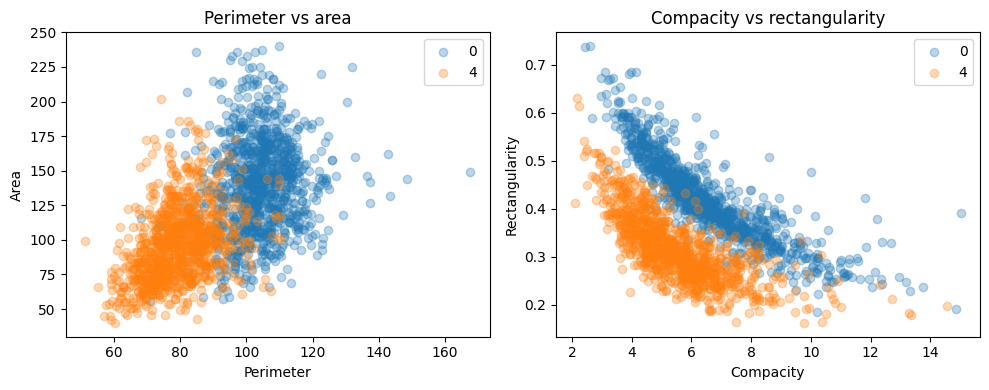

In [74]:
################################################################
############################ TEST ##############################
################################################################

test_3_2(compute_features, images_p_a, images_p_b)